# Phase 05: Feature Validation & Selection
**Objective**

To evaluate whether the engineered features are mathematically correct, statistically meaningful,<br> interpretable, and suitable for downstream preprocessing, PCA, and clustering.

**Inputs**

engineered_dataset.csv<br>
Feature Engineering Specification Sheet<br>
Original questionnaire variables

**Outputs**

Feature Validation Report<br>
Feature Quality Matrix<br>
Final Feature Recommendation

**Assumptions**

All engineered features have already been created.<br>
Original variables are preserved.<br>
No preprocessing has been performed yet.<br>
Expected Deliverables

By the end of this notebook we should know:

Do engineered features have valid ranges?<br>
Do they have sufficient variability?<br>
Are they highly redundant?<br>
Are they statistically consistent?<br>
Should each engineered feature be Kept, Modified, or Dropped?

<h3>Loading the dataset</h3>

In [37]:
import pandas as pd

validation_df = pd.read_csv("dataset\\engineered_dataset.csv")

print(f"Dataset Shape : {validation_df.shape}")
validation_df.head()

Dataset Shape : (15489, 52)


,FRUITS_VEGGIES,DAILY_STRESS,PLACES_VISITED,CORE_CIRCLE,SUPPORTING_OTHERS,SOCIAL_NETWORK,ACHIEVEMENT,DONATION,BMI_RANGE,TODO_COMPLETED,...,WEEKLY_MEDITATION_NORM,DAILY_STRESS_REV,LOST_VACATION_REV,DAILY_SHOUTING_REV,MENTAL_WELLNESS_INDEX,SOCIAL_WELLNESS_INDEX,PHYSICAL_WELLNESS_INDEX,PRODUCTIVITY_INDEX,RECOVERY_WELLBEING_INDEX,STRESS_BURDEN_INDEX
0,3,2,2,5,0,5,2,0,1,6,...,0.5,0.6,0.5,0.5,0.333333,0.333333,0.570370,0.40,0.375,0.466667
1,2,3,4,3,8,10,5,2,2,5,...,0.6,0.4,0.8,0.8,0.366667,0.700000,0.540741,0.50,0.600,0.400000
2,2,3,3,4,4,10,3,2,2,2,...,0.3,0.4,0.0,0.8,0.366667,0.600000,0.503704,0.25,0.475,0.500000
3,3,3,10,3,10,7,2,5,2,3,...,0.0,0.4,0.3,0.5,0.300000,0.666667,0.496296,0.25,0.250,0.700000
4,5,1,3,3,10,4,2,4,2,5,...,0.5,0.8,1.0,1.0,0.266667,0.566667,0.703704,0.35,0.650,0.233333


# 1) Mathematical Validation

In [38]:
engineered_features = [

    "MENTAL_WELLNESS_INDEX",
    "SOCIAL_WELLNESS_INDEX",
    "PHYSICAL_WELLNESS_INDEX",
    "PRODUCTIVITY_INDEX",
    "RECOVERY_WELLBEING_INDEX",
    "STRESS_BURDEN_INDEX"

]

range_validation = pd.DataFrame({

    "Minimum": validation_df[engineered_features].min(),
    "Maximum": validation_df[engineered_features].max()

})

display(range_validation.round(3))

,Minimum,Maximum
MENTAL_WELLNESS_INDEX,0.0,1.0
SOCIAL_WELLNESS_INDEX,0.0,1.0
PHYSICAL_WELLNESS_INDEX,0.0,1.0
PRODUCTIVITY_INDEX,0.0,1.0
RECOVERY_WELLBEING_INDEX,0.0,1.0
STRESS_BURDEN_INDEX,0.0,1.0


Here we can see that the range of the engineered features is correct hence all the features are mathematically correct.

# 2) Distribution Validation

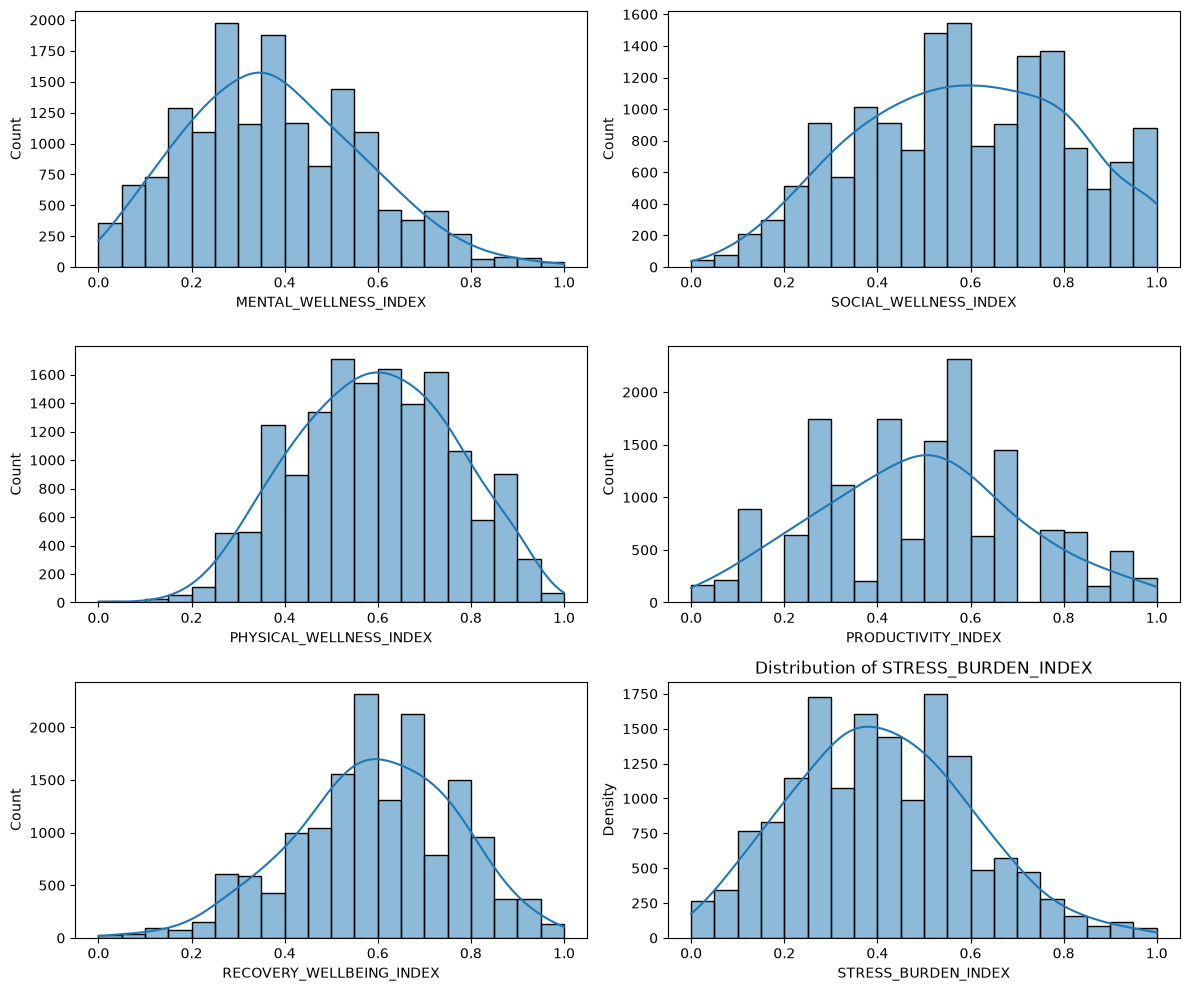

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(engineered_features):
    
    sns.histplot(
        validation_df[feature],
        bins=20,
        kde=True,
        kde_kws={"bw_adjust": 1.8},
        ax = axes[i]
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

# 3) Variance Validation

In [40]:
variance_summary = pd.DataFrame({

    "Variance": validation_df[engineered_features].var(),
    "Standard Deviation": validation_df[engineered_features].std()

})

display(variance_summary.round(4))

,Variance,Standard Deviation
MENTAL_WELLNESS_INDEX,0.0358,0.1893
SOCIAL_WELLNESS_INDEX,0.0512,0.2263
PHYSICAL_WELLNESS_INDEX,0.0288,0.1697
PRODUCTIVITY_INDEX,0.0472,0.2173
RECOVERY_WELLBEING_INDEX,0.0302,0.1738
STRESS_BURDEN_INDEX,0.0371,0.1927


# 4) Relationship Validation

Evaluate whether every engineered feature behaves consistently with the theoretical expectations (with work life balance score) defined during feature engineering.

**FACT**

We engineered features intended to represent healthy lifestyle dimensions.

**ASSUMPTION**

Participants with healthier lifestyles should generally report higher work-life balance.

**HYPOTHESIS**

The wellness indices should show positive relationships with WORK_LIFE_BALANCE_SCORE, while the Stress Burden Index should show a negative relationship.

**LIMITATION**

A relationship does not prove the engineered feature is perfect.

In [41]:
engineered_features = [
    "MENTAL_WELLNESS_INDEX",
    "SOCIAL_WELLNESS_INDEX",
    "PHYSICAL_WELLNESS_INDEX",
    "PRODUCTIVITY_INDEX",
    "RECOVERY_WELLBEING_INDEX",
    "STRESS_BURDEN_INDEX"
]

relationship_results = []

for feature in engineered_features:

    correlation = validation_df[feature].corr(
        validation_df["WORK_LIFE_BALANCE_SCORE"]
    )

    relationship_results.append({
        "Feature": feature,
        "Correlation with Work-Life Balance": correlation
    })

relationship_df = pd.DataFrame(relationship_results)

display(relationship_df.round(3))

,Feature,Correlation with Work-Life Balance
0,MENTAL_WELLNESS_INDEX,0.644
1,SOCIAL_WELLNESS_INDEX,0.662
2,PHYSICAL_WELLNESS_INDEX,0.574
3,PRODUCTIVITY_INDEX,0.685
4,RECOVERY_WELLBEING_INDEX,0.629
5,STRESS_BURDEN_INDEX,-0.516


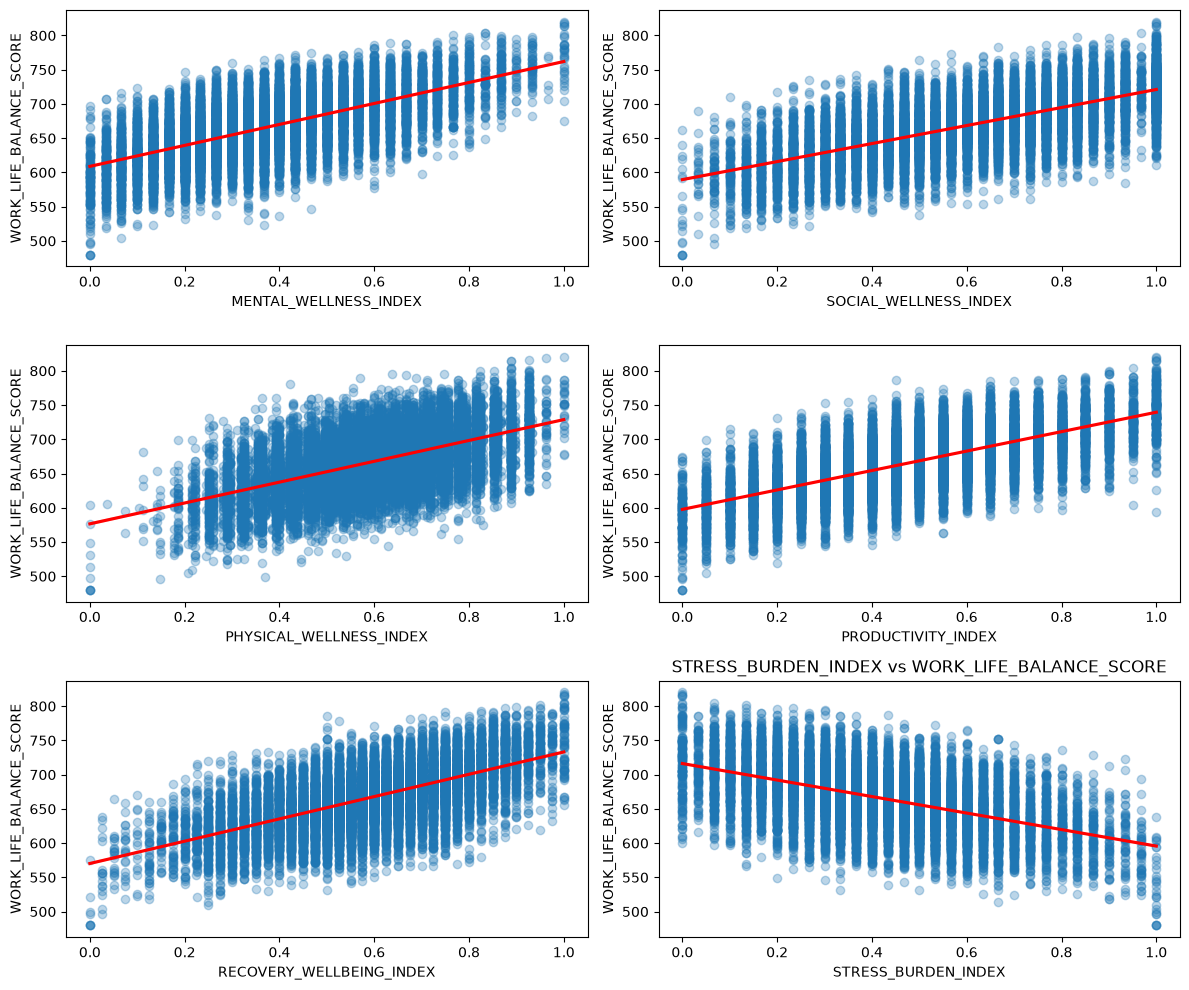

In [42]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(engineered_features):

    sns.regplot(
        data=validation_df,
        x=feature,
        y="WORK_LIFE_BALANCE_SCORE",
        scatter_kws={"alpha":0.3},
        line_kws={"color":"red"},
        ax = axes[i]
    )

    plt.title(f"{feature} vs WORK_LIFE_BALANCE_SCORE")

plt.tight_layout()
plt.show()

In [43]:
validation_summary = relationship_df.copy()

validation_summary["Expected Direction"] = [
    "Positive",
    "Positive",
    "Positive",
    "Positive",
    "Positive",
    "Negative"
]

validation_summary["Observed Direction"] = validation_summary[
    "Correlation with Work-Life Balance"
].apply(
    lambda x: "Positive" if x > 0 else "Negative"
)

validation_summary["Hypothesis Supported"] = (
    validation_summary["Expected Direction"]
    == validation_summary["Observed Direction"]
)

display(validation_summary)

,Feature,Correlation with Work-Life Balance,Expected Direction,Observed Direction,Hypothesis Supported
0,MENTAL_WELLNESS_INDEX,0.643903,Positive,Positive,True
1,SOCIAL_WELLNESS_INDEX,0.661743,Positive,Positive,True
2,PHYSICAL_WELLNESS_INDEX,0.573935,Positive,Positive,True
3,PRODUCTIVITY_INDEX,0.685147,Positive,Positive,True
4,RECOVERY_WELLBEING_INDEX,0.629034,Positive,Positive,True
5,STRESS_BURDEN_INDEX,-0.516130,Negative,Negative,True


# Spearman Analysis

In [44]:
from scipy.stats import spearmanr

spearman_results = []

for feature in engineered_features:

    rho, p_value = spearmanr(
        validation_df[feature],
        validation_df["WORK_LIFE_BALANCE_SCORE"]
    )

    spearman_results.append({
        "Feature": feature,
        "Spearman Correlation": rho,
        "P-value": p_value
    })

spearman_df = pd.DataFrame(spearman_results)

display(spearman_df.round(4))

,Feature,Spearman Correlation,P-value
0,MENTAL_WELLNESS_INDEX,0.6258,0.0
1,SOCIAL_WELLNESS_INDEX,0.6519,0.0
2,PHYSICAL_WELLNESS_INDEX,0.5540,0.0
3,PRODUCTIVITY_INDEX,0.6697,0.0
4,RECOVERY_WELLBEING_INDEX,0.6095,0.0
5,STRESS_BURDEN_INDEX,-0.4927,0.0


# Interpretation

**FACT**

The engineered features exhibit similar linear (Pearson) and monotonic (Spearman) relationships with the target.

**INTERPRETATION**

The relationships are not being driven by a few extreme observations or unusual nonlinear patterns.

**CONCLUSION**

Our relationship validation becomes much stronger because two different correlation methods support the same conclusion.

# Redundancy analysis

In [45]:
feature_mapping = {

    "MENTAL_WELLNESS_INDEX": [
        "DAILY_STRESS",
        "FLOW",
        "LIVE_VISION"
    ],

    "SOCIAL_WELLNESS_INDEX": [
        "CORE_CIRCLE",
        "SUPPORTING_OTHERS",
        "SOCIAL_NETWORK"
    ],

    "PHYSICAL_WELLNESS_INDEX": [
        "FRUITS_VEGGIES",
        "DAILY_STEPS",
        "SLEEP_HOURS"
    ],

    "PRODUCTIVITY_INDEX": [
        "ACHIEVEMENT",
        "TODO_COMPLETED"
    ],

    "RECOVERY_WELLBEING_INDEX": [
        "WEEKLY_MEDITATION",
        "TIME_FOR_PASSION",
        "LOST_VACATION",
        "DAILY_SHOUTING"
    ],

    "STRESS_BURDEN_INDEX": [
        "DAILY_STRESS",
        "DAILY_SHOUTING",
        "WEEKLY_MEDITATION"
    ]
}

In [46]:
# Redundancy Analysis
# Correlation with Parent Variables


redundancy_results = []

for engineered_feature, parent_features in feature_mapping.items():

    for parent in parent_features:

        corr = validation_df[engineered_feature].corr(validation_df[parent])

        redundancy_results.append({
            "Engineered Feature": engineered_feature,
            "Parent Feature": parent,
            "Correlation": corr
        })

redundancy_df = pd.DataFrame(redundancy_results)

display(redundancy_df.round(3))

,Engineered Feature,Parent Feature,Correlation
0,MENTAL_WELLNESS_INDEX,DAILY_STRESS,-0.614
1,MENTAL_WELLNESS_INDEX,FLOW,0.654
2,MENTAL_WELLNESS_INDEX,LIVE_VISION,0.761
3,SOCIAL_WELLNESS_INDEX,CORE_CIRCLE,0.719
4,SOCIAL_WELLNESS_INDEX,SUPPORTING_OTHERS,0.764
5,SOCIAL_WELLNESS_INDEX,SOCIAL_NETWORK,0.736
6,PHYSICAL_WELLNESS_INDEX,FRUITS_VEGGIES,0.751
7,PHYSICAL_WELLNESS_INDEX,DAILY_STEPS,0.774
8,PHYSICAL_WELLNESS_INDEX,SLEEP_HOURS,0.328
9,PRODUCTIVITY_INDEX,ACHIEVEMENT,0.818


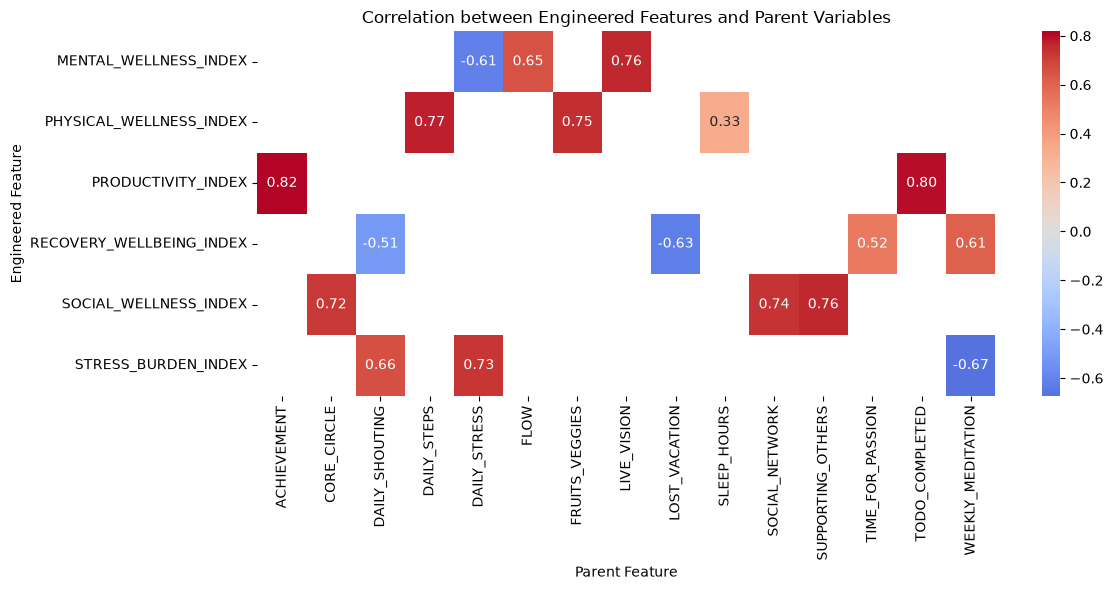

In [47]:
pivot_table = redundancy_df.pivot(
    index="Engineered Feature",
    columns="Parent Feature",
    values="Correlation"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation between Engineered Features and Parent Variables")

plt.tight_layout()

plt.show()

| Correlation                          | Interpretation                        |
| ------------------------------------ | ------------------------------------- |
| 0.30–0.60                            | Weak integration                      |
| 0.60–0.85                            | Healthy summary of multiple variables |
| >0.95 with one parent only           | Possible redundancy                   |
| Similar correlation with all parents | Excellent composite feature           |


In [48]:
parent_summary = (
    redundancy_df
    .groupby("Engineered Feature")["Correlation"]
    .agg(["min", "max", "mean"])
    .round(3)
)

display(parent_summary)

,min,max,mean
Engineered Feature,,,
MENTAL_WELLNESS_INDEX,-0.614,0.761,0.267
PHYSICAL_WELLNESS_INDEX,0.328,0.774,0.618
PRODUCTIVITY_INDEX,0.796,0.818,0.807
RECOVERY_WELLBEING_INDEX,-0.626,0.612,-0.001
SOCIAL_WELLNESS_INDEX,0.719,0.764,0.740
STRESS_BURDEN_INDEX,-0.673,0.728,0.237


**Why did we use the original features instead of the normalized features in redundancy analysis?**

Pearson Correlation Formula

The correlation coefficient is

r=Cov(X,Y)/σXσY

	​
When you multiply or divide an entire variable by a constant (such as dividing by 10 to normalize), both the covariance and the standard deviation change proportionally.

Those changes cancel each other out.

As a result,

r(X,Y)=r(aX+b,Y)

where a>0.

That means:

* Original vs Original<br>
* Original vs Normalized<br>
* Normalized vs Normalized

all produce exactly the same Pearson correlation, provided the transformation is linear.

| Feature               | Mathematical | Distribution | Variance | Relationship | Redundancy         | Final Decision                                           |
| --------------------- | ------------ | ------------ | -------- | ------------ | ------------------ | -------------------------------------------------------- |
| Mental Wellness       | ✅            | ✅            | ✅        | ✅            | ✅                  | Keep                                                     |
| Social Wellness       | ✅            | ✅            | ✅        | ✅            | ✅                  | Keep                                                     |
| Physical Wellness     | ✅            | ✅            | ✅        | ✅            | ✅                  | Keep                                                     |
| Productivity          | ✅            | ✅            | ✅        | ✅            | ✅                  | Keep                                                     |
| Recovery & Well-being | ✅            | ✅            | ✅        | ✅            | ✅                  | Keep                                                     |
| Stress Burden         | ✅            | ✅            | ✅        | ✅            | ⚠ Moderate overlap | **Keep for analysis; evaluate after PCA and clustering** |


# Final Conclusion
**Objective**

To validate the engineered lifestyle indices before they are used in machine learning.

*Summary of Findings*

All engineered features satisfied the expected mathematical range (0–1).<br>
Distribution analysis showed appropriate variability for indices derived from ordinal questionnaire data.<br>
Variance analysis confirmed that no engineered feature exhibited near-zero variance.<br>
Pearson and Spearman correlation analyses supported the hypothesized relationships with WORK_LIFE_BALANCE_SCORE.<br>
Redundancy analysis indicated that each engineered feature integrates information from multiple parent variables rather than duplicating a single questionnaire item.<br>
Feature audit concluded that the engineered indices are statistically valid, interpretable, and suitable for downstream machine learning.<br>
**Final Decision**

The following engineered features are approved for further analysis:

Mental Wellness Index<br>
Social Wellness Index<br>
Physical Wellness Index<br>
Productivity Index<br>
Recovery & Well-being Index<br>
Stress Burden Index (retained for further evaluation during PCA and clustering)<br>
Deliverable

**The validated dataset is now ready for preprocessing.**